# 07b — PCA + Clustering de días (regímenes operativos)

**Objetivo**: identificar regímenes operativos reales del campus a nivel de día,
y comparar los clusters obtenidos con las etiquetas del calendario académico.

**Por qué a nivel de día** (diferencia clave respecto a 07_clustering.ipynb):
- 07_clustering agrupa *horas individuales* usando `Consumo_kWh` como feature → problema:
  está clustering sobre el target, y mezcla horas de días muy distintos.
- Este notebook agrupa *días enteros* usando su **perfil horario de ocupación**
  (vector de 24 valores) → detecta si "agosto-Altre" y "abril-Altre" son
  operativamente distintos, explicando la deriva estacional del fold 4.

**Referencia metodológica**: Wang & Shao (2020) — PCA for feature extraction
followed by DBSCAN/K-Means on WiFi-based occupancy profiles.

**Figuras que genera**:
1. `pca_dias_por_mes.png` — deriva estacional visible en espacio PCA
2. `pca_dias_por_cluster.png` — agrupación operativa descubierta
3. `crosstab_cluster_calendario.png` — dónde el calendario académico "miente"

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PROCESSED = Path('../data/processed')
DATA_RAW       = Path('../data/raw')
FIGURES        = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
print('Libraries loaded OK')

Libraries loaded OK


In [142]:
# ── Cargar datos ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv', parse_dates=['Timestamp'])
print(f'Dataset: {df.shape[0]:,} horas × {df.shape[1]} columnas')
print(f'Rango:   {df["Timestamp"].min().date()} → {df["Timestamp"].max().date()}')

# Normalizar nombres de columna al estándar del pipeline
# (07_clustering.ipynb usa Ocupacion_Simulada; el pipeline usa personas_total)
rename_map = {
    'personas_total':  'Ocupacion_Simulada',
    'temp_c':          'Temperatura',
    'hora':            'Hora',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Columnas mínimas requeridas
required = ['Timestamp', 'Ocupacion_Simulada', 'Consumo_kWh']
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Faltan columnas: {missing}. '
                     f'Columnas disponibles: {df.columns.tolist()}')

df['fecha'] = df['Timestamp'].dt.date
df['hora']  = df['Timestamp'].dt.hour
df['mes']   = df['Timestamp'].dt.month
print('\nOK — columnas necesarias presentes')

Dataset: 8,783 horas × 10 columnas
Rango:   2024-01-01 → 2024-12-31

OK — columnas necesarias presentes


In [143]:
# ── Cargar calendario y unir tipo de día ──────────────────────────────────────
# Ajusta el nombre del archivo si es distinto
cal_path = DATA_RAW / 'Calendari-UPF-2024.csv'
cal = pd.read_csv(cal_path, header=0)
cal.columns = ['fecha_raw', 'tipo_dia']
cal['fecha'] = pd.to_datetime(cal['fecha_raw']).dt.date
cal['tipo_dia'] = cal['tipo_dia'].str.replace('"', '').str.strip()

df = df.merge(cal[['fecha', 'tipo_dia']], on='fecha', how='left')
print('Tipos de día disponibles:')
print(df.groupby('tipo_dia')['fecha'].nunique().sort_values(ascending=False))

Tipos de día disponibles:
tipo_dia
Classe           140
Altre             55
Dissabte          52
Diumenge          52
Avaluacio         30
Vacances          19
Festiu             8
No lectiu          6
La Benvinguda      4
Name: fecha, dtype: int64


## 1. Construir la matriz de días

Cada día se representa como un vector de 24 valores: la ocupación media de cada hora.
Así cada fila de la matriz = 1 día, y tenemos 366 filas × 24 columnas.

In [144]:
# ── Pivot: 1 fila por día, 24 columnas (h0..h23) ─────────────────────────────
pivot = (
    df.pivot_table(index='fecha', columns='hora',
                   values='Ocupacion_Simulada', aggfunc='mean')
    .fillna(0)
)
pivot.columns = [f'h{int(h):02d}' for h in pivot.columns]

# Añadir metadatos útiles (no se usan como features, solo para colorear)
meta = df.groupby('fecha').agg(
    mes      = ('mes',      'first'),
    tipo_dia = ('tipo_dia', 'first'),
    consumo_medio = ('Consumo_kWh', 'mean'),
).reset_index()

pivot = pivot.reset_index().merge(meta, on='fecha')

print(f'Matriz de días: {pivot.shape[0]} días × {len([c for c in pivot.columns if c.startswith("h")])} horas')
print(f'Tipos de día en la matriz:')
print(pivot['tipo_dia'].value_counts())

Matriz de días: 366 días × 24 horas
Tipos de día en la matriz:
tipo_dia
Classe           140
Altre             55
Dissabte          52
Diumenge          52
Avaluacio         30
Vacances          19
Festiu             8
No lectiu          6
La Benvinguda      4
Name: count, dtype: int64


## 2. PCA: 24 dimensiones → 2 componentes principales

In [145]:
hora_cols = [c for c in pivot.columns if c.startswith('h')]
X         = pivot[hora_cols].values

# Escalar antes del PCA (cada hora tiene escala diferente)
scaler = StandardScaler()
X_std  = scaler.fit_transform(X)

pca    = PCA(n_components=3, random_state=42)
X_pca  = pca.fit_transform(X_std)

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada:')
print(f'  PC1: {var_exp[0]*100:.1f}%')
print(f'  PC2: {var_exp[1]*100:.1f}%')
print(f'  PC3: {var_exp[2]*100:.1f}%')
print(f'  PC1+PC2: {(var_exp[0]+var_exp[1])*100:.1f}%  ← lo que veremos en los scatters')

pivot['PC1'] = X_pca[:, 0]
pivot['PC2'] = X_pca[:, 1]
pivot['PC3'] = X_pca[:, 2]

Varianza explicada:
  PC1: 88.9%
  PC2: 6.9%
  PC3: 2.4%
  PC1+PC2: 95.8%  ← lo que veremos en los scatters


## Figura 1 — PCA scatter coloreado por mes

Si el modelo tiene deriva estacional (fold 4), los meses de verano
deberían aparecer separados del resto en este espacio.

C:\Users\jordi\AppData\Local\Temp\ipykernel_32916\542541312.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mes = plt.cm.get_cmap('twilight_shifted', 12)


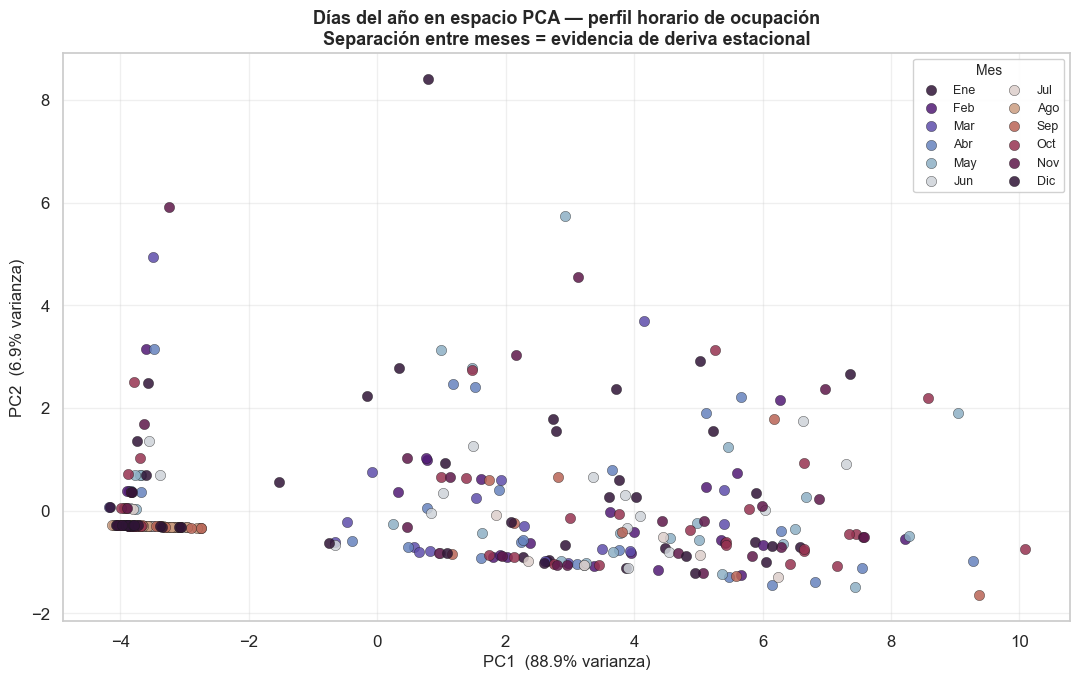

✅ Guardado: pca_dias_por_mes.png


In [146]:
MESES_ES = ['Ene','Feb','Mar','Abr','May','Jun',
            'Jul','Ago','Sep','Oct','Nov','Dic']

# Paleta cíclica tipo 'twilight' para que Dic y Ene queden cerca visualmente
cmap_mes = plt.cm.get_cmap('twilight_shifted', 12)

fig, ax = plt.subplots(figsize=(11, 7))

for mes_num in range(1, 13):
    mask = pivot['mes'] == mes_num
    ax.scatter(
        pivot.loc[mask, 'PC1'],
        pivot.loc[mask, 'PC2'],
        color=cmap_mes(mes_num - 1),
        s=55, edgecolors='k', linewidths=0.3,
        label=MESES_ES[mes_num - 1], alpha=0.85, zorder=3
    )

ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title(
    'Días del año en espacio PCA — perfil horario de ocupación\n'
    'Separación entre meses = evidencia de deriva estacional',
    fontsize=13, fontweight='bold'
)

ax.legend(title='Mes', loc='upper right',
          ncol=2, fontsize=9, title_fontsize=10,
          framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_dias_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: pca_dias_por_mes.png')

## 3. Elegir k óptimo — silhouette + elbow

k con mayor silhouette: 2  (score=0.716)
Silhouette por k:
  k=2: 0.716
  k=3: 0.661
  k=4: 0.670
  k=5: 0.624
  k=6: 0.637
  k=7: 0.628
  k=8: 0.628


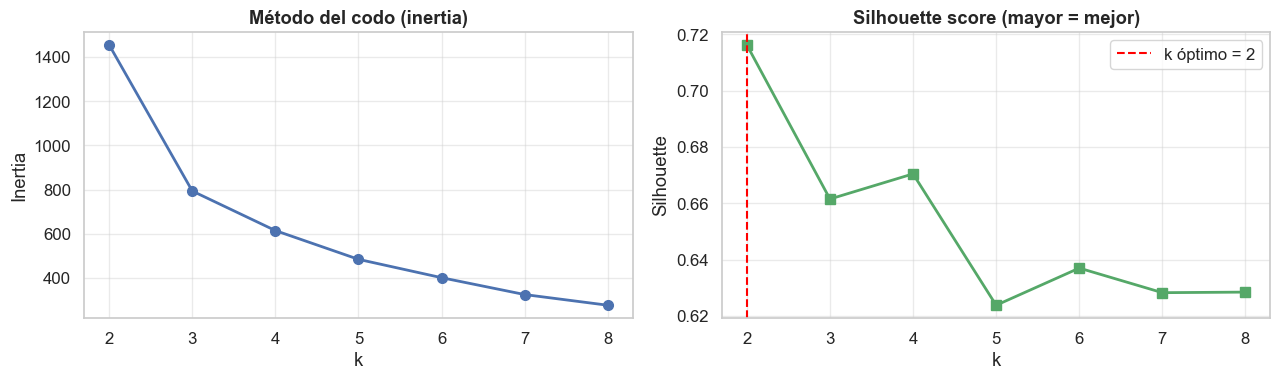

In [147]:
inercias  = []
sil_scores = []
K_RANGE   = range(2, 9)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca[:, :2])   # usamos PC1+PC2
    inercias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca[:, :2], labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inercias, marker='o', lw=2, ms=7)
axes[0].set_title('Método del codo (inertia)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.4)

axes[1].plot(list(K_RANGE), sil_scores, marker='s', lw=2, ms=7, color='C2')
axes[1].set_title('Silhouette score (mayor = mejor)', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].grid(alpha=0.4)

k_opt_sil = list(K_RANGE)[np.argmax(sil_scores)]
axes[1].axvline(k_opt_sil, color='red', ls='--', lw=1.5,
                label=f'k óptimo = {k_opt_sil}')
axes[1].legend()

print(f'k con mayor silhouette: {k_opt_sil}  (score={max(sil_scores):.3f})')
print('Silhouette por k:')
for k, s in zip(K_RANGE, sil_scores):
    print(f'  k={k}: {s:.3f}')

plt.tight_layout()
plt.savefig(FIGURES / 'pca_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

In [148]:
# ── Fijar k (ajusta si el elbow/silhouette sugieren otro) ─────────────────────
# Por defecto usamos el k óptimo por silhouette.
# Si el elbow sugiere un k diferente más interpretable, cámbialo aquí.
K_FINAL = 4
print(f'K_FINAL = {K_FINAL}')

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
pivot['cluster'] = km_final.fit_predict(X_pca[:, :2])

# Renombrar clusters por consumo medio (0=menor, K-1=mayor → más interpretable)
orden_consumo = (
    pivot.groupby('cluster')['consumo_medio']
    .mean().sort_values().index.tolist()
)
rename_cl = {old: new for new, old in enumerate(orden_consumo)}
pivot['cluster'] = pivot['cluster'].map(rename_cl)

print('\nCaracterísticas medias por cluster:')
print(pivot.groupby('cluster')[['consumo_medio'] +
      [f'h{h:02d}' for h in [8,12,16,20]]].mean().round(1))

K_FINAL = 4

Características medias por cluster:
         consumo_medio    h08     h12     h16     h20
cluster                                              
0                130.3   29.5   233.2   281.2     2.9
1                216.0  159.5  1210.9   890.1   466.6
2                239.7  187.2  1427.8  1078.3   658.2
3                242.5  281.9  2189.7  1701.3  1094.2


In [149]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    s_scores = silhouette_samples(X_pca, labels)
    
    print(f'k={k}:  silhouette_mean={s_scores.mean():.3f}  '
          f'min={s_scores.min():.3f}  '
          f'max={s_scores.max():.3f}')
    print(f'  Clusters con silhouette negativo: '
          f'{(s_scores < 0).sum()} puntos')

k=2:  silhouette_mean=0.697  min=-0.041  max=0.916
  Clusters con silhouette negativo: 2 puntos
k=3:  silhouette_mean=0.631  min=-0.075  max=0.909
  Clusters con silhouette negativo: 3 puntos
k=4:  silhouette_mean=0.642  min=-0.046  max=0.917
  Clusters con silhouette negativo: 4 puntos
k=5:  silhouette_mean=0.589  min=-0.182  max=0.905
  Clusters con silhouette negativo: 8 puntos


## Figura 2 — PCA scatter coloreado por cluster

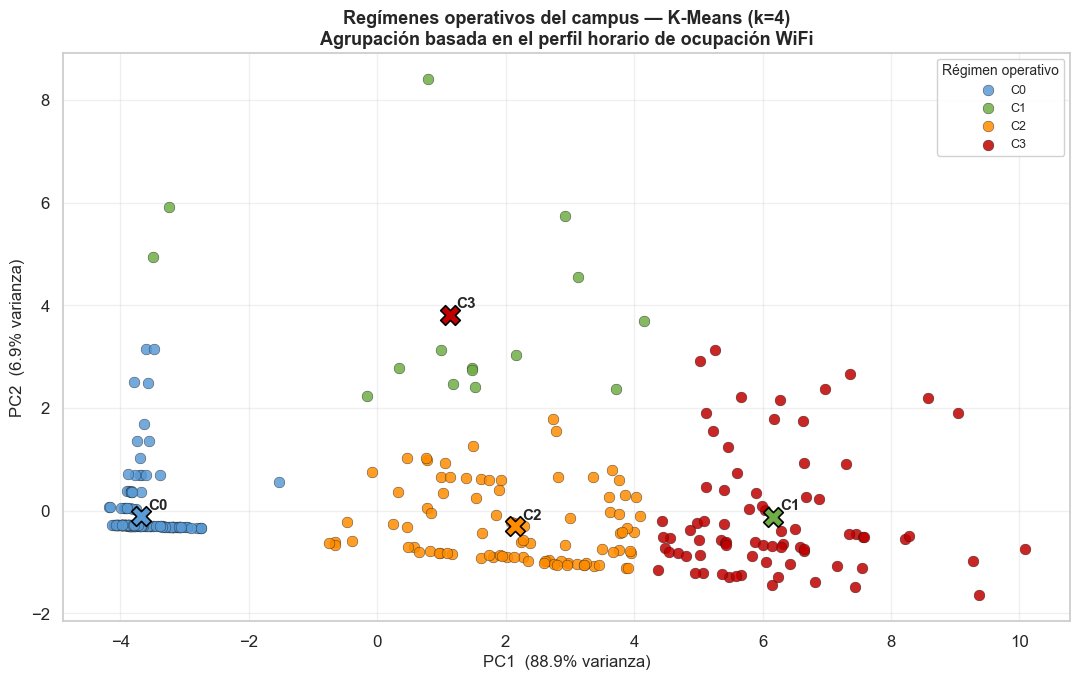

✅ Guardado: pca_dias_por_cluster.png


In [150]:
NOMBRES_CLUSTER = [
    'C0',
    'C1',
    'C2',
    'C3',
    'C4',
][:K_FINAL]   

PALETA_CL = ['#5B9BD5', '#70AD47', '#FF8C00', '#C00000', '#7030A0'][:K_FINAL]

fig, ax = plt.subplots(figsize=(11, 7))

for cl in range(K_FINAL):
    mask = pivot['cluster'] == cl
    ax.scatter(
        pivot.loc[mask, 'PC1'],
        pivot.loc[mask, 'PC2'],
        color=PALETA_CL[cl], s=60,
        edgecolors='k', linewidths=0.3,
        label=NOMBRES_CLUSTER[cl], alpha=0.85, zorder=3
    )

# Marcar los centroides
centroides = km_final.cluster_centers_
for cl in range(K_FINAL):
    ax.scatter(centroides[cl, 0], centroides[cl, 1],
               marker='X', s=200, color=PALETA_CL[cl],
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(f'C{cl}', (centroides[cl, 0], centroides[cl, 1]),
                fontsize=11, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f'PC1  ({var_exp[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2  ({var_exp[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title(
    f'Regímenes operativos del campus — K-Means (k={K_FINAL})\n'
    'Agrupación basada en el perfil horario de ocupación WiFi',
    fontsize=13, fontweight='bold'
)
ax.legend(title='Régimen operativo', loc='upper right',
          fontsize=9, title_fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_dias_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: pca_dias_por_cluster.png')

## Figura 3 — Cross-tab: cluster × tipo_dia del calendario

Esta es la figura clave: muestra dónde el calendario académico
agrupa bajo la misma etiqueta días que son operativamente distintos.

**Interpretación esperada**:
- Classe / Avaluació → deberían concentrarse en un cluster alto
- Dissabte / Diumenge → deberían concentrarse en el cluster mínimo
- **Altre → debería aparecer en múltiples clusters** (es el tipo de día
  más heterogéneo: incluye laborables de verano y de invierno)

In [151]:
# ── Cross-tab normalizado por fila (% de cada tipo_dia en cada cluster) ───────
cross_raw = pd.crosstab(pivot['tipo_dia'], pivot['cluster'])
cross_pct = cross_raw.div(cross_raw.sum(axis=1), axis=0).round(3) * 100

# Ordenar tipos de día de más a menos lectivos
ORDEN_TIPOS = [
    'Classe', 'La Benvinguda', 'Avaluacio', 'No lectiu',
    'Altre', 'Vacances', 'Dissabte', 'Diumenge', 'Festiu'
]
orden_disponible = [t for t in ORDEN_TIPOS if t in cross_pct.index]
resto = [t for t in cross_pct.index if t not in orden_disponible]
cross_pct = cross_pct.reindex(orden_disponible + resto)

# Renombrar columnas para el plot
cross_pct.columns = [f'C{c}' for c in cross_pct.columns]

print('Cross-tab (% de cada tipo_dia distribuido por cluster):')
print(cross_pct.round(1).to_string())

Cross-tab (% de cada tipo_dia distribuido por cluster):
                  C0    C1     C2    C3
tipo_dia                               
Classe           0.7   7.1   42.9  49.3
La Benvinguda    0.0   0.0  100.0   0.0
Avaluacio        0.0   6.7   70.0  23.3
No lectiu        0.0  16.7   83.3   0.0
Altre          100.0   0.0    0.0   0.0
Vacances       100.0   0.0    0.0   0.0
Dissabte        96.2   3.8    0.0   0.0
Diumenge       100.0   0.0    0.0   0.0
Festiu         100.0   0.0    0.0   0.0


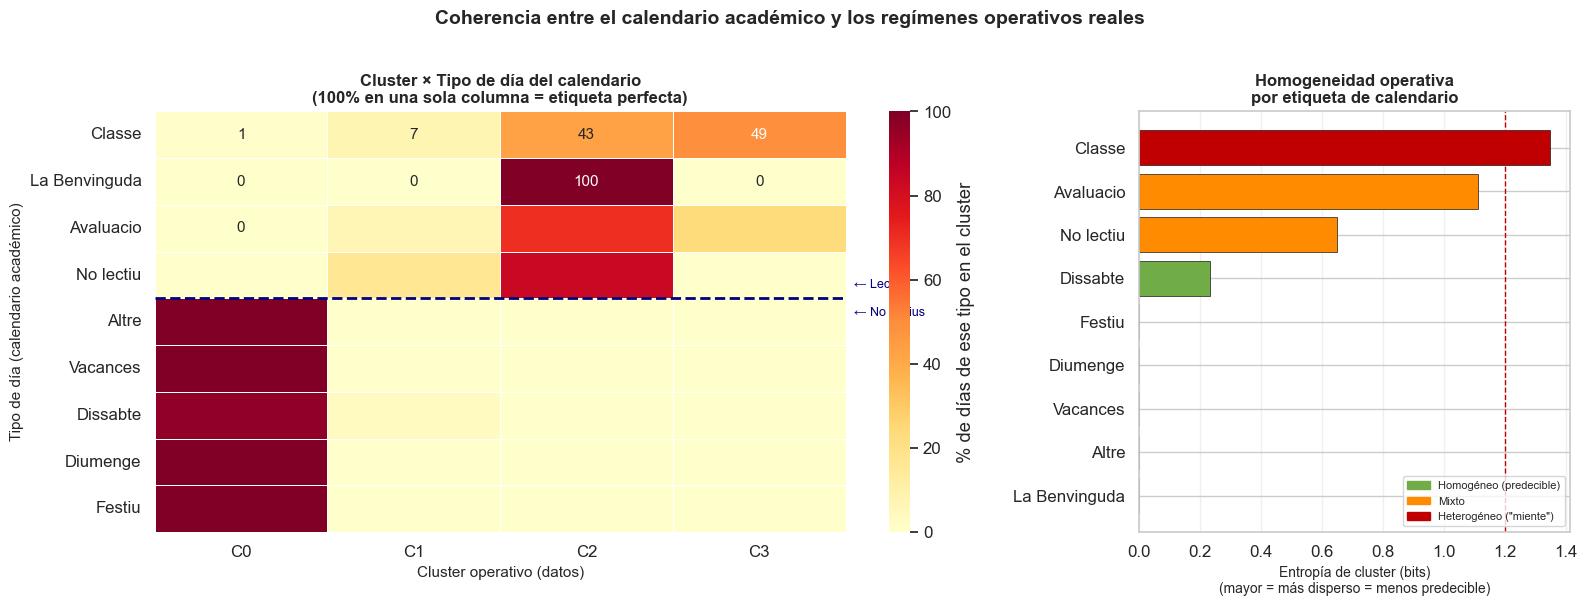

✅ Guardado: crosstab_cluster_calendario.png


In [152]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [2, 1]})

# ── Panel izquierdo: heatmap ──────────────────────────────────────────────────
sns.heatmap(
    cross_pct,
    annot=True, fmt='.0f', annot_kws={'size': 11},
    cmap='YlOrRd', linewidths=0.5,
    cbar_kws={'label': '% de días de ese tipo en el cluster'},
    ax=axes[0]
)
axes[0].set_title(
    'Cluster × Tipo de día del calendario\n'
    '(100% en una sola columna = etiqueta perfecta)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Cluster operativo (datos)', fontsize=11)
axes[0].set_ylabel('Tipo de día (calendario académico)', fontsize=11)

# Línea separadora entre días lectivos y no lectivos
n_lectivos = len([t for t in cross_pct.index
                  if t in ['Classe','La Benvinguda','Avaluacio','No lectiu']])
axes[0].axhline(n_lectivos, color='navy', lw=2, ls='--')
axes[0].text(cross_pct.shape[1] + 0.05, n_lectivos - 0.3,
             '← Lectius', fontsize=9, color='navy', va='center')
axes[0].text(cross_pct.shape[1] + 0.05, n_lectivos + 0.3,
             '← No lectius', fontsize=9, color='navy', va='center')

# ── Panel derecho: entropía por tipo de día ───────────────────────────────────
# Entropía alta = tipo de día muy disperso en clusters → calendario "miente"
def entropia(row):
    p = row[row > 0] / 100
    return -np.sum(p * np.log2(p))

entropia_serie = cross_pct.apply(entropia, axis=1).sort_values(ascending=True)
max_entropia   = np.log2(K_FINAL)  # entropía máxima teórica

colores_entr = ['#C00000' if e > max_entropia * 0.6 else
                '#FF8C00' if e > max_entropia * 0.3 else
                '#70AD47'
                for e in entropia_serie]

axes[1].barh(entropia_serie.index, entropia_serie.values,
              color=colores_entr, edgecolor='k', linewidth=0.5)
axes[1].axvline(max_entropia * 0.6, color='#C00000', ls='--', lw=1,
                label='Umbral "miente" (>60% entropia)')
axes[1].set_xlabel('Entropía de cluster (bits)\n(mayor = más disperso = menos predecible)', fontsize=10)
axes[1].set_title('Homogeneidad operativa\npor etiqueta de calendario', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(alpha=0.3, axis='x')

patches = [
    mpatches.Patch(color='#70AD47', label='Homogéneo (predecible)'),
    mpatches.Patch(color='#FF8C00', label='Mixto'),
    mpatches.Patch(color='#C00000', label='Heterogéneo ("miente")'),
]
axes[1].legend(handles=patches, fontsize=8, loc='lower right')

plt.suptitle(
    'Coherencia entre el calendario académico y los regímenes operativos reales',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / 'crosstab_cluster_calendario.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: crosstab_cluster_calendario.png')

## 4. Interpretación cuantitativa

In [153]:
print('═' * 60)
print('INTERPRETACIÓN DEL CLUSTERING')
print('═' * 60)

# Tipos de día con entropía alta (el calendario "miente")
umbral_miente = max_entropia * 0.6
miente = entropia_serie[entropia_serie > umbral_miente]
print(f'\nTipos de día con alta dispersión de cluster (calendario "miente"):')
for tipo, entr in miente.sort_values(ascending=False).items():
    dias_tipo = cross_raw.loc[tipo].sum()
    print(f'  {tipo:20s}  entropia={entr:.2f}  n_dias={dias_tipo}')

# Confirmar hipótesis del fold 4: Altre en verano vs Altre en primavera
if 'Altre' in pivot['tipo_dia'].values:
    print(f'\nDistribución de "Altre" por mes y cluster:')
    alt = pivot[pivot['tipo_dia'] == 'Altre'][['mes','cluster']]
    print(pd.crosstab(alt['mes'], alt['cluster'],
                      rownames=['Mes'], colnames=['Cluster']))
    print('  → Si Altre de jul-ago está en un cluster distinto a Altre de ene-abr,')
    print('    confirma que el bias del fold 4 es una limitación del calendario,')  
    print('    no del modelo.')

# Exportar tabla cluster → tipo_dia para la memoria
pivot[['fecha','tipo_dia','cluster','consumo_medio']].to_csv(
    DATA_PROCESSED / 'dias_con_cluster.csv', index=False
)
print(f'\n✅ Dataset con clusters guardado en data/processed/dias_con_cluster.csv')

════════════════════════════════════════════════════════════
INTERPRETACIÓN DEL CLUSTERING
════════════════════════════════════════════════════════════

Tipos de día con alta dispersión de cluster (calendario "miente"):
  Classe                entropia=1.35  n_dias=140

Distribución de "Altre" por mes y cluster:
Cluster   0
Mes        
6         5
7        17
8        22
9        11
  → Si Altre de jul-ago está en un cluster distinto a Altre de ene-abr,
    confirma que el bias del fold 4 es una limitación del calendario,
    no del modelo.

✅ Dataset con clusters guardado en data/processed/dias_con_cluster.csv


In [154]:
# ── Clustering A: por OCUPACIÓN → feature del modelo ─────────────────────────
# Ya lo tienes en 07b. Propósito: mejorar predicción.
# Defensable: no usa el target.

# ── Clustering B: por CONSUMO → análisis descriptivo ─────────────────────────
# Nuevo. Propósito: caracterizar regímenes energéticos.
# NO se usa como feature del modelo.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Pivot: 1 fila por día, 24 columnas de consumo medio por hora
pivot_consumo = (
    df.pivot_table(index='fecha', columns='hora',
                   values='Consumo_kWh', aggfunc='mean')
    .fillna(0)
)
pivot_consumo.columns = [f'kwh_h{int(h):02d}' for h in pivot_consumo.columns]

# Metadatos
meta = df.groupby('fecha').agg(
    mes           = ('mes',              'first'),
    tipus_dia     = ('tipus_dia',        'first'),
    ocupacio_mitja = ('Ocupacion_Simulada','mean'),
    consum_mitja  = ('Consumo_kWh',      'mean'),
).reset_index()

# PCA + KMeans igual que en 07b
X = pivot_consumo.values
X_std = StandardScaler().fit_transform(X)
pca_c = PCA(n_components=3, random_state=42)
X_pca_c = pca_c.fit_transform(X_std)

print(f'Varianza explicada por consumo:')
print(f'  PC1: {pca_c.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca_c.explained_variance_ratio_[1]*100:.1f}%')

km_c = KMeans(n_clusters=4, random_state=42, n_init=20)
pivot_consumo_meta = pivot_consumo.reset_index().merge(meta, on='fecha')
pivot_consumo_meta['cluster_consumo'] = km_c.fit_predict(X_pca_c[:, :2])

Varianza explicada por consumo:
  PC1: 66.3%
  PC2: 17.5%


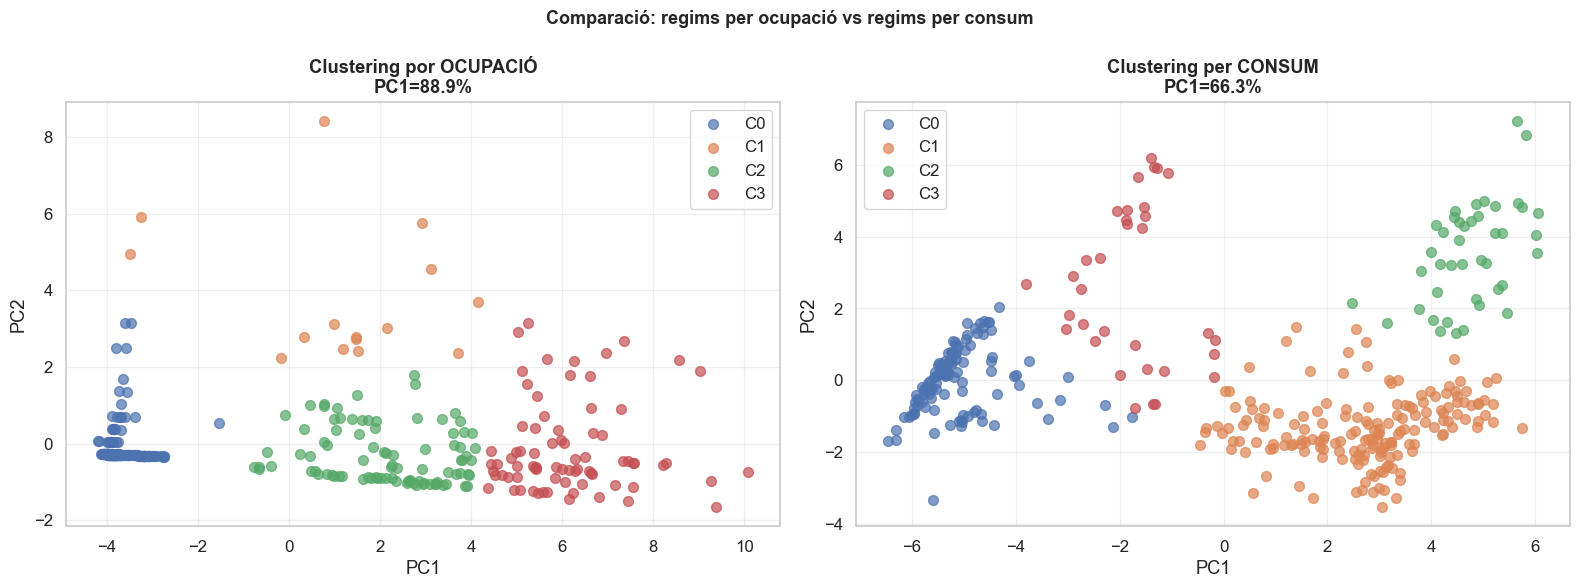

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clustering por ocupación (ya calculado en 07b)
for cl in range(4):
    mask = pivot['cluster'] == cl
    axes[0].scatter(pivot.loc[mask,'PC1'], pivot.loc[mask,'PC2'],
                    s=50, alpha=0.7, label=f'C{cl}')
axes[0].set_title(f'Clustering por OCUPACIÓ\nPC1={var_exp[0]*100:.1f}%',
                   fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Clustering por consumo (nuevo)
for cl in range(4):
    mask = pivot_consumo_meta['cluster_consumo'] == cl
    axes[1].scatter(X_pca_c[mask, 0], X_pca_c[mask, 1],
                    s=50, alpha=0.7, label=f'C{cl}')
axes[1].set_title(f'Clustering per CONSUM\nPC1={pca_c.explained_variance_ratio_[0]*100:.1f}%',
                   fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Comparació: regims per ocupació vs regims per consum',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'clustering_ocupacio_vs_consum.png', dpi=150, bbox_inches='tight')
plt.show()

In [156]:
# Necesitas las coordenadas PCA del espacio de consumo
pca_scores = pca_c.transform(X_std)   # X_std = consumo estandarizado

pivot_consumo_meta['PC1_consumo'] = pca_scores[:, 0]
pivot_consumo_meta['PC2_consumo'] = pca_scores[:, 1]

# AHORA sí: el outlier es el mínimo de PC2
outlier_idx = pivot_consumo_meta['PC2_consumo'].idxmin()
print(pivot_consumo_meta.loc[outlier_idx,
      ['fecha','tipus_dia','mes','consum_mitja','ocupacio_mitja','PC2_consumo']])

fecha              2024-10-01
tipus_dia              Classe
mes                        10
consum_mitja       242.083333
ocupacio_mitja    1206.541667
PC2_consumo         -3.532827
Name: 274, dtype: object


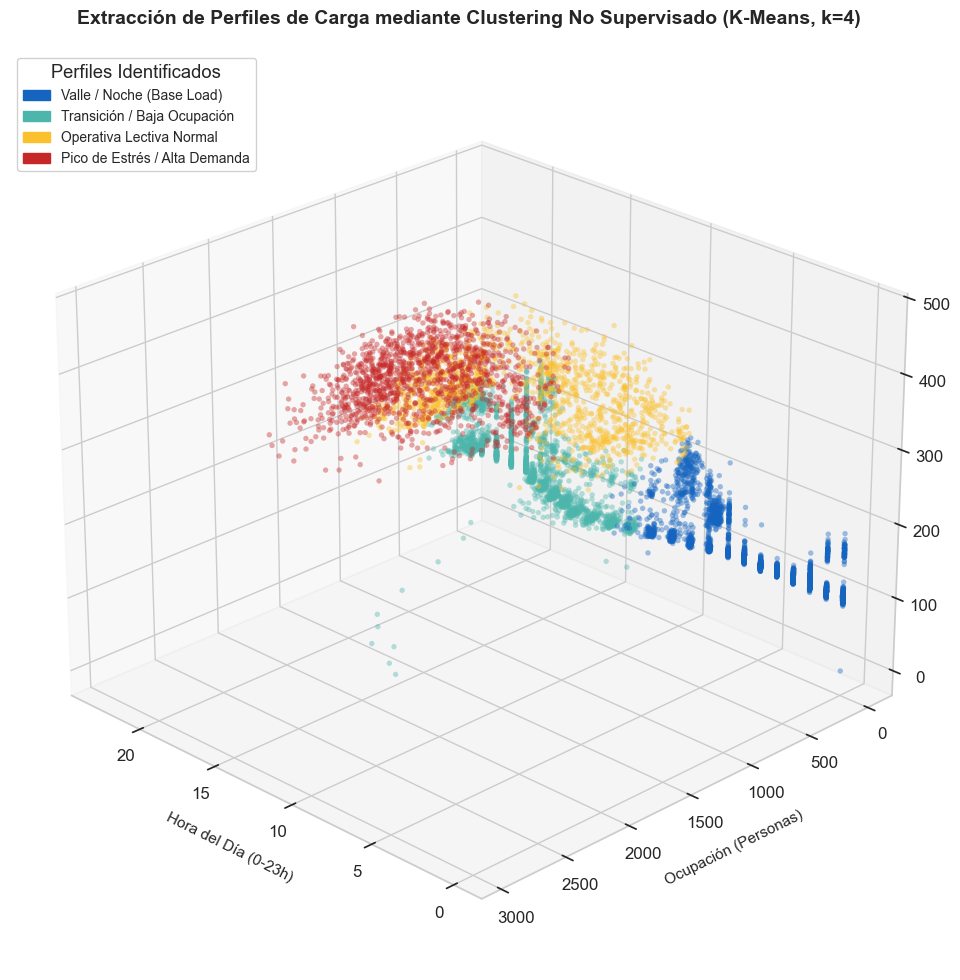

=== RESUMEN DE LOS CLÚSTERES (Para la memoria) ===
                         Nombre_Perfil  Hora_Dia  Ocupacion_Simulada  \
Cluster                                                                
0            Valle / Noche (Base Load)       4.7                29.8   
1        Pico de Estrés / Alta Demanda      14.1              1595.9   
2          Transición / Baja Ocupación      18.8               132.6   
3             Operativa Lectiva Normal      14.9               666.7   

         Consumo_kWh  Horas_Totales  
Cluster                              
0              113.5           3730  
1              379.9           1338  
2              127.2           2418  
3              291.0           1297  


In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches

# 1. Preparar los datos (Asegúrate de que Timestamp sea datetime)
if not np.issubdtype(df['Timestamp'].dtype, np.datetime64):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Hora_Dia'] = df['Timestamp'].dt.hour

# Seleccionar las 3 dimensiones clave para el clustering
features = ['Hora_Dia', 'Ocupacion_Simulada', 'Consumo_kWh']
X = df[features].dropna().copy()

# 2. Estandarizar los datos (OBLIGATORIO para K-Means, si no los kWh aplastan a las horas)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Entrenar K-Means con k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Asignar etiquetas semánticas a los clústeres (esto puede variar según tus datos,
# pero matemáticamente el algoritmo suele separarlos así):
# Averiguamos qué clúster es cuál mirando sus medias
medias = X.groupby('Cluster').mean()

# Ordenar los clústeres por consumo para darles un nombre lógico
orden_consumo = medias.sort_values('Consumo_kWh').index
nombres_clusters = {
    orden_consumo[0]: 'Valle / Noche (Base Load)',
    orden_consumo[1]: 'Transición / Baja Ocupación',
    orden_consumo[2]: 'Operativa Lectiva Normal',
    orden_consumo[3]: 'Pico de Estrés / Alta Demanda'
}

colores_hex = ['#1565C0', '#4DB6AC', '#FBC02D', '#C62828'] # Azul, Turquesa, Amarillo, Rojo
mapa_colores = {orden_consumo[i]: colores_hex[i] for i in range(4)}

# 5. Dibujar el Gráfico 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
scatter = ax.scatter(X['Hora_Dia'], X['Ocupacion_Simulada'], X['Consumo_kWh'],
                     c=X['Cluster'].map(mapa_colores),
                     alpha=0.4, s=15, edgecolors='none')

# Etiquetas de los ejes
ax.set_xlabel('Hora del Día (0-23h)', fontsize=11, labelpad=10)
ax.set_ylabel('Ocupación (Personas)', fontsize=11, labelpad=10)
ax.set_zlabel('Consumo Eléctrico (kWh)', fontsize=11, labelpad=10)
ax.set_title('Extracción de Perfiles de Carga mediante Clustering No Supervisado (K-Means, k=4)', 
             fontsize=14, fontweight='bold', pad=20)

# Leyenda personalizada
legend_patches = [mpatches.Patch(color=colores_hex[i], label=nombres_clusters[orden_consumo[i]]) for i in range(4)]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10, framealpha=0.9, title="Perfiles Identificados")

# Ajustar el ángulo de visión (Prueba a cambiar estos números si quieres girar el gráfico)
ax.view_init(elev=25, azim=135)

plt.tight_layout()
# plt.savefig('clustering_3d_campus.png', dpi=200, bbox_inches='tight')
plt.show()

# Imprimir el resumen estadístico para tu memoria
print("=== RESUMEN DE LOS CLÚSTERES (Para la memoria) ===")
resumen = X.groupby('Cluster').mean().round(1)
resumen['Nombre_Perfil'] = resumen.index.map(nombres_clusters)
resumen['Horas_Totales'] = X.groupby('Cluster').size()
print(resumen[['Nombre_Perfil', 'Hora_Dia', 'Ocupacion_Simulada', 'Consumo_kWh', 'Horas_Totales']])